In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import mode

In [2]:
data = pd.read_csv("/home/apiiit123/Downloads/classification and regression/Mall_Customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
numerical = data.select_dtypes(["int","float"]).columns
categorical = data.select_dtypes(["category","object"]).columns

In [17]:
label = LabelEncoder()
data["Gender"] = label.fit_transform(data["Gender"])

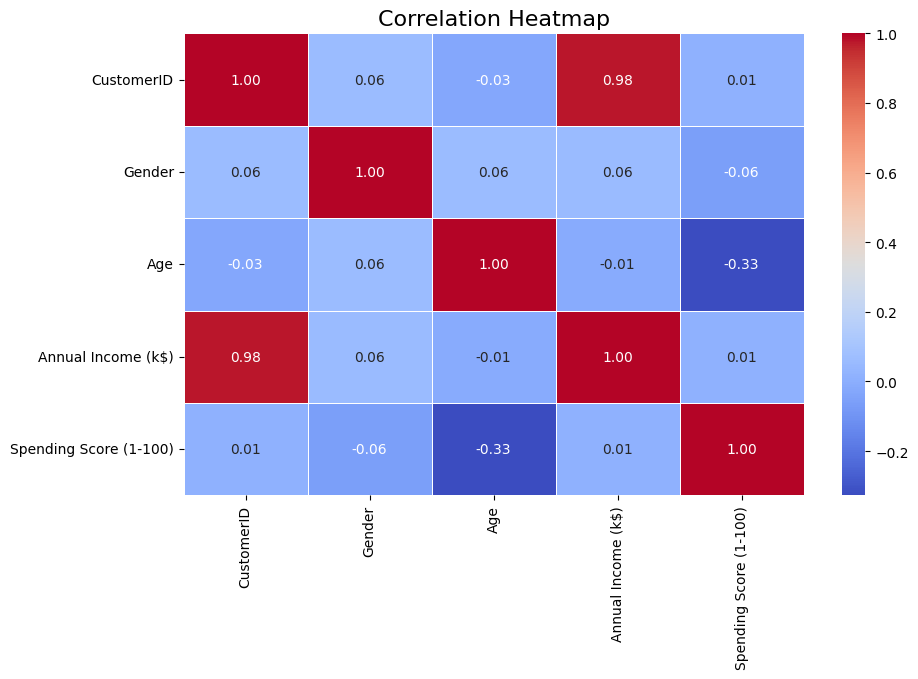

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [22]:
X = data.drop(columns = ["Gender"],axis = 1)
y = data["Gender"]

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [34]:
#  PCA (2D Projection)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

In [35]:
# ELBOW METHOD TO FIND OPTIMAL K
wcss = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

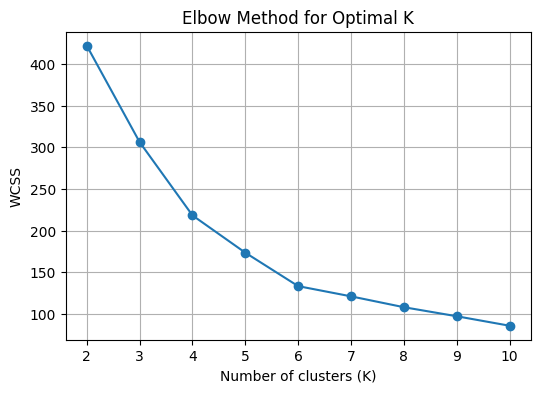

In [36]:
plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [37]:
# FIT K-MEANS WITH CHOSEN K
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train)

In [41]:
# Assign clusters to train & test
train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)

In [42]:
# Evaluation (Silhouette Score)
sil_score_train = silhouette_score(X_train, train_clusters)
sil_score_test = silhouette_score(X_test, test_clusters)
print(f"Silhouette Score (Train): {sil_score_train:.3f}")
print(f"Silhouette Score (Test): {sil_score_test:.3f}")

Silhouette Score (Train): 0.350
Silhouette Score (Test): 0.311


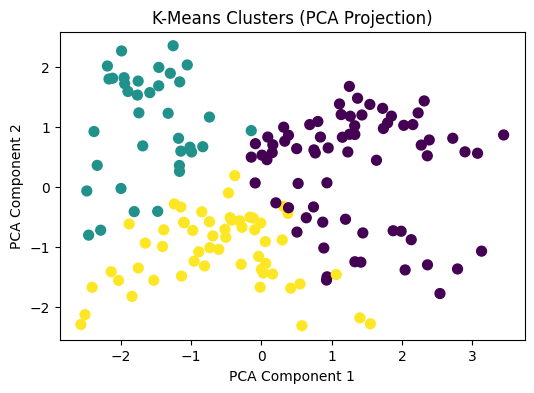

In [38]:
# 8. VISUALIZE CLUSTERS
plt.figure(figsize=(6, 4))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [39]:
# EVALUATE CLUSTERING
sil_score = silhouette_score(X_train, cluster_labels)
print(f"Silhouette Score for K={optimal_k}: {sil_score:.3f}")

Silhouette Score for K=3: 0.350


In [40]:
# PREDICT TEST DATA CLUSTERS
test_labels = kmeans.predict(X_test)
print("Test Cluster Assignments:", test_labels)

Test Cluster Assignments: [0 1 2 0 2 0 1 0 0 1 2 0 0 1 0 0 2 0 2 1 0 1 0 2 1 2 1 2 0 0 1 2 2 1 0 2 0
 0 0 2]


In [44]:
labels_map = {}
for cluster in np.unique(train_clusters):
    mask = (train_clusters == cluster)
    labels_map[cluster] = mode(y_train[mask], keepdims=True)[0][0]

In [45]:
mapped_train_preds = np.vectorize(labels_map.get)(train_clusters)
mapped_test_preds = np.vectorize(labels_map.get)(test_clusters)

In [46]:
# Accuracy
print("\nAccuracy (Train):", accuracy_score(y_train, mapped_train_preds))
print("Accuracy (Test):", accuracy_score(y_test, mapped_test_preds))


Accuracy (Train): 0.56875
Accuracy (Test): 0.525


In [47]:
# Classification Report
print("\nClassification Report (Test):\n", classification_report(y_test, mapped_test_preds))


Classification Report (Test):
               precision    recall  f1-score   support

           0       0.53      1.00      0.69        21
           1       0.00      0.00      0.00        19

    accuracy                           0.53        40
   macro avg       0.26      0.50      0.34        40
weighted avg       0.28      0.53      0.36        40



/home/apiiit123/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/apiiit123/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/apiiit123/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


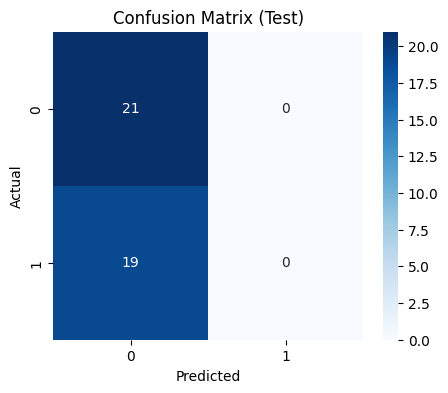

In [48]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, mapped_test_preds), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()